# Paw vigor across labs — and how it squares with the wheel

Two results that look incompatible:

- the **wheel** trajectory carries a clear lab effect (0.149 of its variance, p = 0.002)
- **paw vigor** carries none (0.056, p = 0.18) — and neither does paw asymmetry (0.000)

Yet the mouse turns the wheel with its paws. This notebook resolves that, and on the way
runs into a correction that manufactures the effect it was meant to remove.

Computation lives in `paw_vigor.py`; this notebook reads its output and plots it.

In [1]:
"""SETUP"""
import sys, pathlib, importlib
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

_p = pathlib.Path.cwd().resolve()
while not (_p / 'paper_style.py').exists() and _p != _p.parent:
    _p = _p.parent
for _sub in ['', '4_mice', 'learning_individuality', 'lab']:
    sys.path.insert(0, str(_p / _sub) if _sub else str(_p))
import paper_style as ps; importlib.reload(ps); ps.use('paper')
import variance_partition as vp; importlib.reload(vp)
import functions
import lab_effect_three_featuresets as L

HERE = pathlib.Path.cwd()
C_LAB, C_MOUSE, C_SESS = '#B3472A', '#2F3A34', '#C3C6BE'
V = pd.read_csv(HERE / 'paw_vigor.csv').set_index('session')
# the rulers live in the geometry table; paw_vigor.csv carries only the two it divides by
_geo = pd.read_csv(HERE / 'rig_geometry.csv', index_col=0)
for _c in ['pupil_diam_px']:
    V[_c] = _geo[_c].reindex(V.index)
print(f'{len(V)} sessions, {V.mouse.nunique()} mice, {V.lab.nunique()} labs')


def partition(D, lb, ms, n_perm=3000):
    vc, _ = vp.nested_variance_components(D, lb, ms)
    s = vc.clip(lower=0).sum() if D.shape[1] > 1 else vc.clip(lower=0).iloc[0]
    s = s / s.sum()
    _, _, pv = vp.permutation_null_eta2(D, lb, ms, n_perm=n_perm, seed=0)
    return s['sigma2_lab'], s['sigma2_mouse'], s['sigma2_session'], pv


def partition_bars(ax, rows, labels, title, note=None):
    """rows = list of (lab, mouse, session, p)"""
    bottom = np.zeros(len(rows))
    for j, (colr, lab) in enumerate([(C_LAB, 'Lab'), (C_MOUSE, 'Mouse'), (C_SESS, 'Session')]):
        vals = np.array([r[j] for r in rows])
        ax.bar(np.arange(len(rows)), vals, bottom=bottom, color=colr, label=lab, width=.62)
        bottom += vals
    for i, r in enumerate(rows):
        ax.text(i, 1.02, f'p = {r[3]:.3f}' if r[3] >= .001 else 'p < 0.001', ha='center',
                fontsize=plt.rcParams['font.size'] * 0.55,
                color=C_LAB if r[3] < .05 else '0.45')
    ax.set_xticks(np.arange(len(rows)))
    ax.set_xticklabels(labels, fontsize=plt.rcParams['font.size'] * 0.55)
    # headroom for the p labels, so they never run into the title
    ax.set_ylim(0, 1.14); ax.set_yticks(np.arange(0, 1.01, .2))
    ax.set_ylabel('Share of variance')
    ax.set_title(title, fontsize=plt.rcParams['font.size'] * 0.78, pad=26)
    if note:
        ax.text(0, -0.28, note, transform=ax.transAxes, va='top',
                fontsize=plt.rcParams['font.size'] * 0.55, color='0.4')

paper_style: paper mode, spines=lb, font 7 pt, panels 3.4x2.4 in, save 400 dpi
269 sessions, 58 mice, 10 labs


## 1. Four ways to measure vigor

Ordered by how much optics each can carry. `vigor_px` is exposed to zoom; `vigor_tube`
divides it by the lick tube's apparent length (rigid hardware, so a px/mm ruler in the same
frame); `vigor_syll` moves only with which paw states a session occupies; `vigor_LA` is the
fraction of frames lightningAction calls active — a rate, which optics cannot scale.

wrote figures/paw_vigor_measures_18-09-2026.png, figures/paw_vigor_measures_18-09-2026.svg


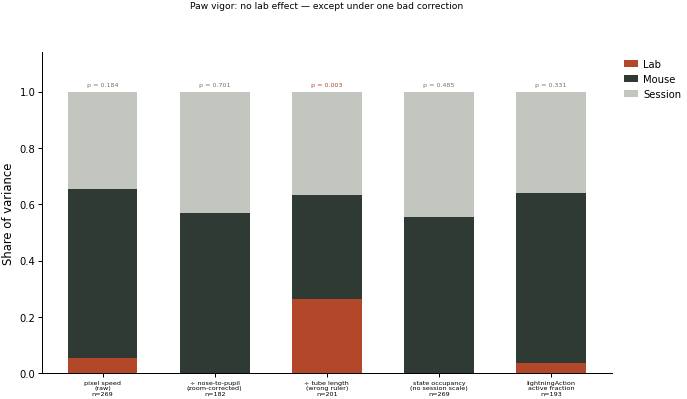

  vigor_px     lab 0.056  mouse 0.599  session 0.345   p=0.1838
  vigor_pupil  lab 0.000  mouse 0.568  session 0.432   p=0.7008
  vigor_tube   lab 0.262  mouse 0.369  session 0.369   p=0.0026
  vigor_syll   lab 0.000  mouse 0.554  session 0.446   p=0.4854
  vigor_LA     lab 0.038  mouse 0.601  session 0.361   p=0.3314


In [2]:
"""VIGOR MEASURES"""
MEAS = {'vigor_px': 'pixel speed\n(raw)',
        'vigor_pupil': '÷ nose-to-pupil\n(zoom-corrected)',
        'vigor_tube': '÷ tube length\n(wrong ruler)',
        'vigor_syll': 'state occupancy\n(no session scale)',
        'vigor_LA': 'lightningAction\nactive fraction'}
rows, labels = [], []
for m, lab in MEAS.items():
    D = V[[m]].dropna()
    rows.append(partition(D, V.loc[D.index, 'lab'], V.loc[D.index, 'mouse'], n_perm=5000))
    labels.append(f'{lab}\nn={len(D)}')
fig, ax = ps.figure('wide', scale=1.25)
partition_bars(ax, rows, labels, 'Paw vigor: no lab effect — except under one bad correction')
ax.legend(frameon=False, bbox_to_anchor=(1.01, 1), loc='upper left')
fig.tight_layout(); ps.savefig(fig, 'paw_vigor_measures', svg=True); plt.show()
for m, r in zip(MEAS, rows):
    print(f'  {m:12s} lab {r[0]:.3f}  mouse {r[1]:.3f}  session {r[2]:.3f}   p={r[3]:.4f}')

## 2. Two rulers, and why only one of them works

`vigor_tube` is the only measure with a lab effect — and it is a correction I introduced to
*remove* optics. The reason is that the lick tube is **not fixed hardware**: it can be cut
longer or shorter between rigs, so its apparent length confounds magnification with how
someone trimmed the spout.

Nose tip to pupil centre is the better ruler. It is a distance **on the animal**, at roughly
the depth the paws move in, so it scales with magnification and not with rig assembly:

| ruler | lab | mouse | session | predicts paw speed |
|---|---|---|---|---|
| `tube_len_px` | 0.420 | 0.018 | **0.562** | r = +0.072 (p = 0.31) |
| `nose_to_pupil_px` | **0.885** | 0.090 | **0.025** | **r = +0.278 (p = 0.0001)** |
| `pupil_diam_px` | 0.260 | 0.212 | 0.528 | r = +0.197 |

Over half the tube's variance is session-to-session — a bolted-down object should not move,
so that is trimming plus tracking wobble. Nose-to-pupil is stable within a rig and actually
predicts pixel speed, which is the property a zoom ruler needs.

variance structure of each ruler, and whether it predicts paw speed


  tube_len_px        n=201  lab 0.420  mouse 0.018  session 0.562   vs paw speed r = +0.072 (p=0.31)


  nose_to_pupil_px   n=182  lab 0.885  mouse 0.090  session 0.025   vs paw speed r = +0.278 (p=0.00014)


  pupil_diam_px      n=200  lab 0.260  mouse 0.212  session 0.528   vs paw speed r = +0.197 (p=0.0053)


wrote figures/paw_vigor_zoom_rulers_18-09-2026.png, figures/paw_vigor_zoom_rulers_18-09-2026.svg


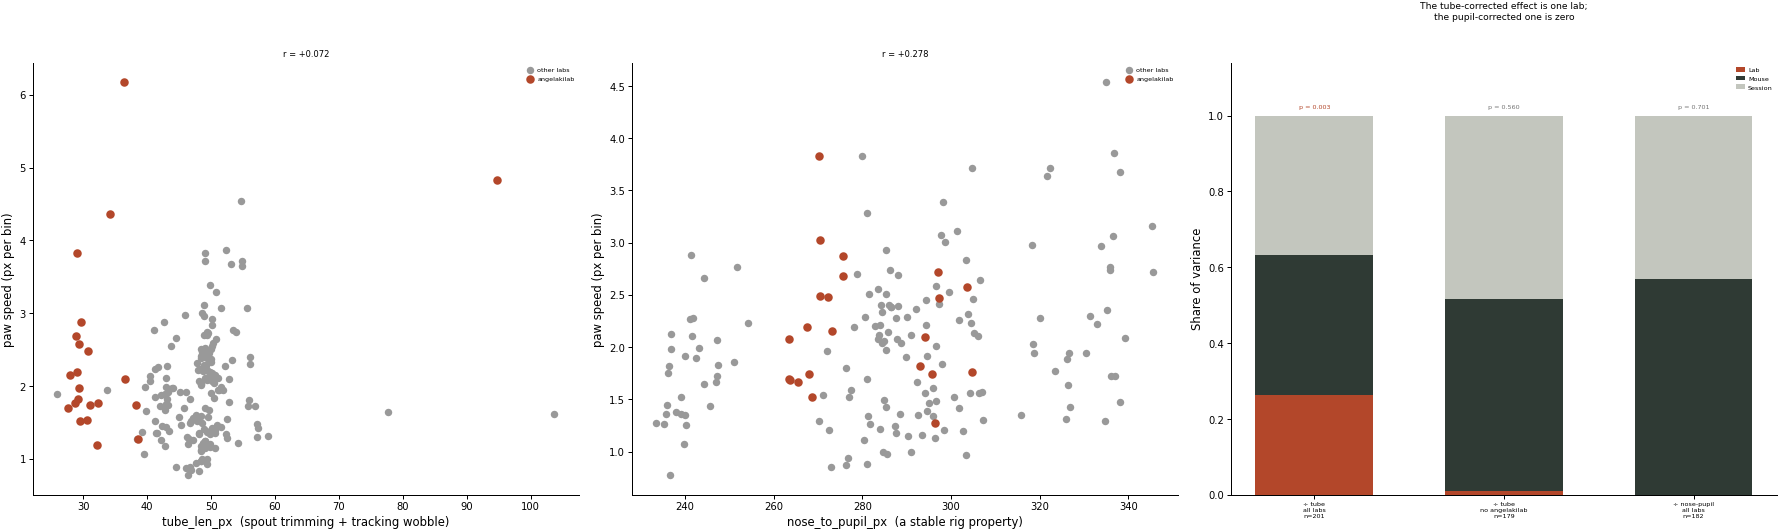

In [3]:
"""TWO RULERS"""
RULERS = ['tube_len_px', 'nose_to_pupil_px', 'pupil_diam_px']
print('variance structure of each ruler, and whether it predicts paw speed')
for c in RULERS:
    D = V[[c]].dropna()
    r = partition(D, V.loc[D.index, 'lab'], V.loc[D.index, 'mouse'])
    q = V[['vigor_px', c]].dropna()
    rr = stats.pearsonr(q['vigor_px'], q[c])
    print(f'  {c:18s} n={len(D):3d}  lab {r[0]:.3f}  mouse {r[1]:.3f}  session {r[2]:.3f}'
          f'   vs paw speed r = {rr[0]:+.3f} (p={rr[1]:.2g})')

fig, axs = plt.subplots(1, 3, figsize=(15, 4.6))
for ax, c, note in zip(axs[:2], ['tube_len_px', 'nose_to_pupil_px'],
                       ['spout trimming + tracking wobble', 'a stable rig property']):
    q = V[['vigor_px', c, 'lab']].dropna()
    ang = (q['lab'] == 'angelakilab').to_numpy()
    ax.scatter(q[c][~ang], q['vigor_px'][~ang], s=20, color='0.6', linewidths=0, label='other labs')
    ax.scatter(q[c][ang], q['vigor_px'][ang], s=26, color=C_LAB, linewidths=0, label='angelakilab')
    rr = stats.pearsonr(q['vigor_px'], q[c])
    ax.set_xlabel(f'{c}  ({note})'); ax.set_ylabel('paw speed (px per bin)')
    ax.set_title(f'r = {rr[0]:+.3f}', fontsize=plt.rcParams['font.size'] * 0.72)
    ax.legend(frameon=False, fontsize=plt.rcParams['font.size'] * 0.55)

rows2, labels2 = [], []
for col, keep, lab in [('vigor_tube', V.lab == V.lab, '÷ tube\nall labs'),
                       ('vigor_tube', V.lab != 'angelakilab', '÷ tube\nno angelakilab'),
                       ('vigor_pupil', V.lab == V.lab, '÷ nose-pupil\nall labs')]:
    Dv = V.loc[keep, [col]].dropna()
    rows2.append(partition(Dv, V.loc[Dv.index, 'lab'], V.loc[Dv.index, 'mouse'], n_perm=5000))
    labels2.append(f'{lab}\nn={len(Dv)}')
partition_bars(axs[2], rows2, labels2, 'The tube-corrected effect is one lab;\nthe pupil-corrected one is zero')
axs[2].legend(frameon=False, fontsize=plt.rcParams['font.size'] * 0.55)
fig.tight_layout(); ps.savefig(fig, 'paw_vigor_zoom_rulers', svg=True); plt.show()

## 3. Reconciling with the wheel: trajectory versus scalar

The wheel result was a **40-bin trajectory**; vigor is a **scalar**. Putting all four on the
same sessions shows the split is between those two, not between wheel and paw.

252 sessions, 55 mice, 10 labs
  wheel 40-bin trajectory      lab 0.149  mouse 0.462  p=0.0020
  paw 160-bin trajectory       lab 0.088  mouse 0.485  p=0.0000
  wheel scalar                 lab 0.080  mouse 0.438  p=0.1430
  paw scalar                   lab 0.090  mouse 0.491  p=0.1700
wrote figures/wheel_vs_paw_trajectory_scalar_18-09-2026.png, figures/wheel_vs_paw_trajectory_scalar_18-09-2026.svg


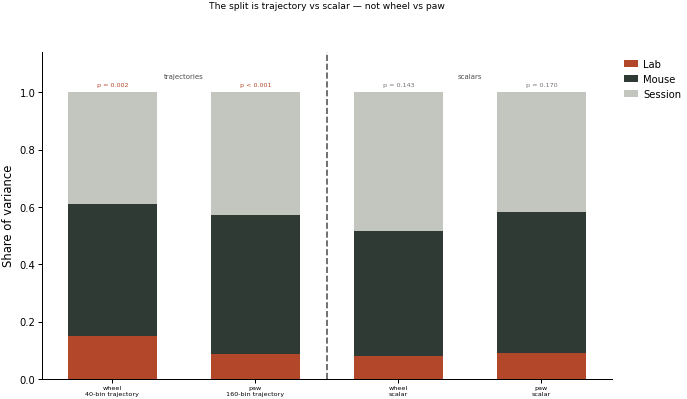

In [4]:
"""MATCHED COMPARISON"""
syl, dd = functions.build_design_matrix(L.SYLLABLES, n_paw_states=8, verbose=False)
mouse = pd.Series(syl.index.map(dd[['mouse_name', 'session']].drop_duplicates()
                                .set_index('session')['mouse_name']), index=syl.index)
raw, _ = functions.build_design_matrix(str(_p / 'data' / '10_bin_raw_10-09-2026'), verbose=False)
wh = pd.read_parquet(HERE / 'wheel_10bin_sequences.pqt')
w, X = L._pivot(wh)
X = (X - np.nanmean(X, axis=0)) / np.nanstd(X, axis=0)
wheel = L._per_session(X, w['session'])

order = [s for s in syl.index if s in set(raw.index) and s in set(wheel.index) and s in set(V.index)]
lb = functions.lab_labels(pd.Index(order), mouse_names=mouse[order], verbose=False)
ms = mouse[order]
ch = np.arange(raw.shape[1]) // 40
RAW_PAW = ch >= 2
blocks = {
    'wheel\n40-bin trajectory': wheel.loc[order],
    'paw\n160-bin trajectory': raw.loc[order].iloc[:, RAW_PAW],
    'wheel\nscalar': pd.DataFrame({'mean': wheel.loc[order].mean(1), 'sd': wheel.loc[order].std(1)}),
    'paw\nscalar': V.loc[order, ['vigor_px']],
}
rows3 = [partition(D, lb, ms) for D in blocks.values()]
print(f'{len(order)} sessions, {ms.nunique()} mice, {lb.nunique()} labs')
for nm, r in zip(blocks, rows3):
    print(f"  {nm.replace(chr(10),' '):28s} lab {r[0]:.3f}  mouse {r[1]:.3f}  p={r[3]:.4f}")

fig, ax = ps.figure('wide', scale=1.25)
partition_bars(ax, rows3, list(blocks), 'The split is trajectory vs scalar — not wheel vs paw')
ax.axvline(1.5, color='0.35', lw=1, ls='--')
ax.text(0.5, 1.05, 'trajectories', ha='center', fontsize=plt.rcParams['font.size'] * .6, color='0.3')
ax.text(2.5, 1.05, 'scalars', ha='center', fontsize=plt.rcParams['font.size'] * .6, color='0.3')
ax.legend(frameon=False, bbox_to_anchor=(1.01, 1), loc='upper left')
fig.tight_layout(); ps.savefig(fig, 'wheel_vs_paw_trajectory_scalar', svg=True); plt.show()

## 4. Where the wheel's extra lab variance sits

The wheel trajectory is still more lab-structured than the paw trajectory (0.149 vs 0.088).
Splitting by epoch says where the excess is — and it is not where the wheel is being turned.

wrote figures/wheel_vs_paw_by_epoch_18-09-2026.png, figures/wheel_vs_paw_by_epoch_18-09-2026.svg


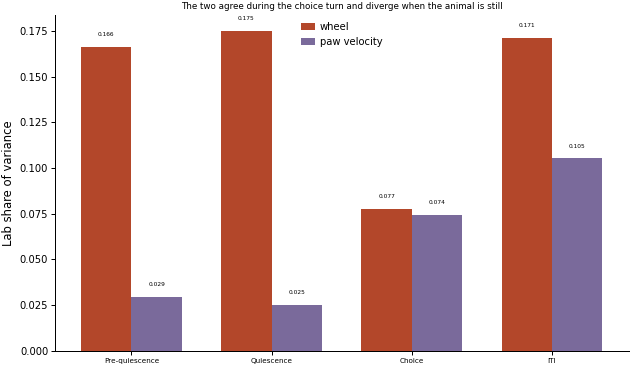

In [5]:
"""PER-EPOCH"""
EP = ['Pre-quiescence', 'Quiescence', 'Choice', 'ITI']
out = {}
for nm, D, epi, ep_order in [
        ('wheel', wheel.loc[order], np.repeat(np.arange(4), 10), EP),
        ('paw', raw.loc[order].iloc[:, RAW_PAW], np.tile(np.repeat(np.arange(4), 10), 4),
         ['Choice', 'ITI', 'Pre-quiescence', 'Quiescence'])]:
    vc, _ = vp.nested_variance_components(D, lb, ms)
    cl = vc.clip(lower=0)
    vals = {}
    for i in range(4):
        t = cl[epi == i].sum()
        vals[ep_order[i]] = t['sigma2_lab'] / t.sum()
    out[nm] = [vals[e] for e in EP]

fig, ax = ps.figure('wide', scale=1.15)
x = np.arange(4); wdt = .36
ax.bar(x - wdt/2, out['wheel'], wdt, color=C_LAB, label='wheel')
ax.bar(x + wdt/2, out['paw'], wdt, color='#7A6A9B', label='paw velocity')
ax.set_xticks(x); ax.set_xticklabels(EP, fontsize=plt.rcParams['font.size'] * .62)
ax.set_ylabel('Lab share of variance')
ax.set_title('The two agree during the choice turn and diverge when the animal is still',
             fontsize=plt.rcParams['font.size'] * 0.75)
ax.legend(frameon=False)
for xi, (a, b) in enumerate(zip(out['wheel'], out['paw'])):
    ax.text(xi - wdt/2, a + .006, f'{a:.3f}', ha='center', fontsize=plt.rcParams['font.size'] * .5)
    ax.text(xi + wdt/2, b + .006, f'{b:.3f}', ha='center', fontsize=plt.rcParams['font.size'] * .5)
fig.tight_layout(); ps.savefig(fig, 'wheel_vs_paw_by_epoch', svg=True); plt.show()

## 5. Do whisking and licking scale with zoom?

Paw vigor does not need a zoom correction. Whisk and lick are the channels that carry the lab
effect, so the question is whether *they* are optically driven. Zoom here is
`nose_to_pupil_px` — nose tip to pupil centre, a distance on the animal, which is 88.5% lab
and only 2.5% session.

176 sessions, 47 mice, 9 labs


wrote figures/whisk_lick_vs_zoom_18-09-2026.png, figures/whisk_lick_vs_zoom_18-09-2026.svg


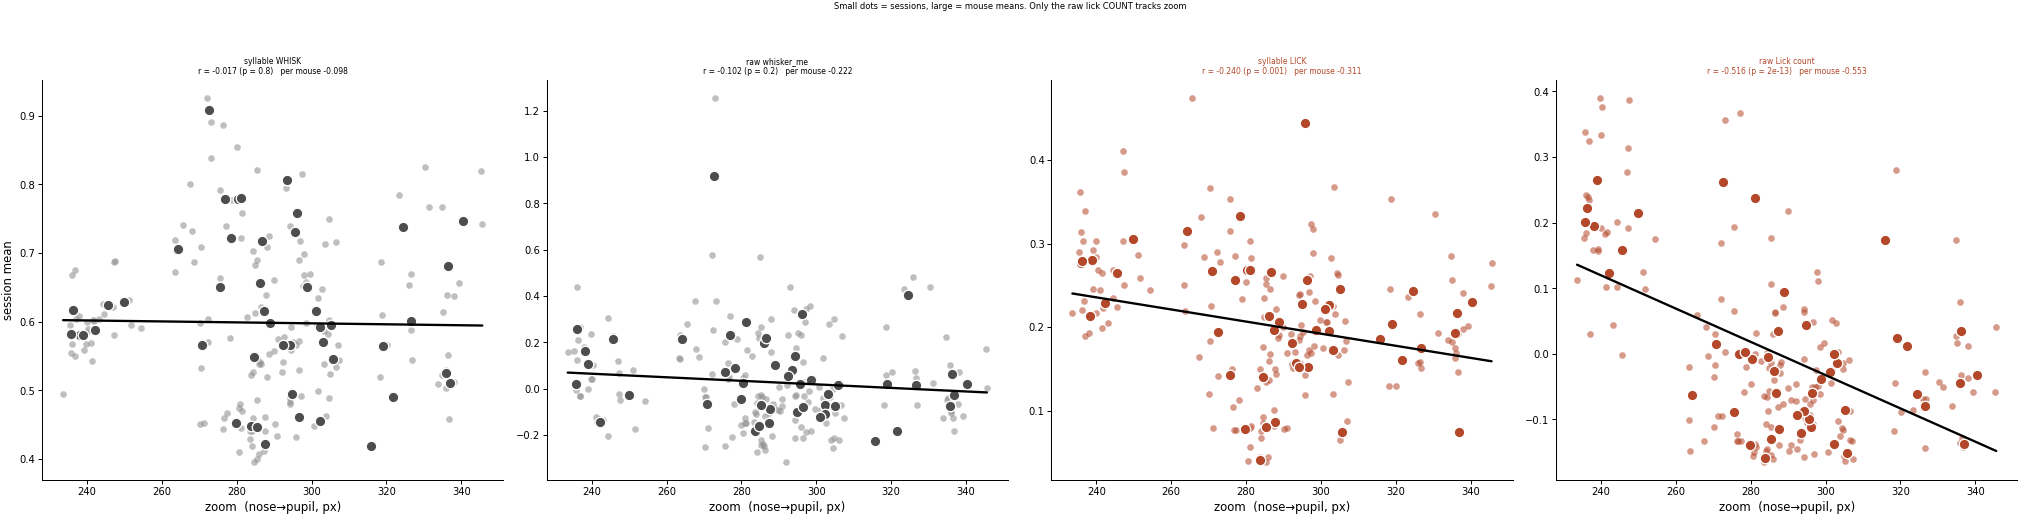

In [6]:
"""WHISK / LICK AGAINST ZOOM"""
geo = pd.read_csv(HERE / 'rig_geometry.csv', index_col=0)
z_all = geo['nose_to_pupil_px'].dropna()
zorder = [s for s in syl.index if s in set(raw.index) and s in z_all.index]
zlab = functions.lab_labels(pd.Index(zorder), mouse_names=mouse[zorder], verbose=False)
zms, zz = mouse[zorder], z_all[zorder]
wcol = np.arange(syl.shape[1]); rcol = np.arange(raw.shape[1]) // 40
CHAN = {'syllable WHISK': syl.loc[zorder].iloc[:, (wcol % 9) == 7],
        'raw whisker_me': raw.loc[zorder].iloc[:, rcol == 1],
        'syllable LICK': syl.loc[zorder].iloc[:, (wcol % 9) == 8],
        'raw Lick count': raw.loc[zorder].iloc[:, rcol == 0]}
print(f'{len(zorder)} sessions, {zms.nunique()} mice, {zlab.nunique()} labs')

fig, axs = plt.subplots(1, 4, figsize=(17, 4.2))
for ax, (nm, D) in zip(axs, CHAN.items()):
    m = D.mean(axis=1)
    r = stats.pearsonr(m, zz)
    pm = pd.DataFrame({'m': m, 'z': zz, 'mouse': zms}).groupby('mouse').mean()
    rm = stats.pearsonr(pm['m'], pm['z'])
    strong = r[1] < 0.01
    ax.scatter(zz, m, s=16, color=(C_LAB if strong else '0.55'), alpha=.55, linewidths=0)
    ax.scatter(pm['z'], pm['m'], s=40, color=(C_LAB if strong else '0.3'),
               edgecolor='white', linewidths=.8, zorder=3)
    lo, hi = zz.min(), zz.max()
    a, b = np.polyfit(zz, m, 1)
    ax.plot([lo, hi], [a*lo + b, a*hi + b], color='k', lw=1.4, zorder=4)
    ax.set_xlabel('zoom  (nose→pupil, px)')
    ax.set_ylabel('session mean' if nm == list(CHAN)[0] else '')
    ax.set_title(f'{nm}\nr = {r[0]:+.3f} (p = {r[1]:.1g})   per mouse {rm[0]:+.3f}',
                 fontsize=plt.rcParams['font.size'] * 0.65,
                 color=(C_LAB if strong else 'k'))
fig.suptitle('Small dots = sessions, large = mouse means. Only the raw lick COUNT tracks zoom',
             fontsize=plt.rcParams['font.size'] * 0.72, y=1.04)
fig.tight_layout(); ps.savefig(fig, 'whisk_lick_vs_zoom', svg=True); plt.show()

### …and does holding zoom fixed remove the lab effect?

Zoom tertiles cut across labs, so the lab effect can be re-estimated *within* a zoom group.
If zoom were the cause, the bars would collapse.

labs spanning >1 zoom group: 6 of 9; zoom groups with >1 lab: 3 of 3


wrote figures/whisk_lick_lab_within_zoom_18-09-2026.png, figures/whisk_lick_lab_within_zoom_18-09-2026.svg


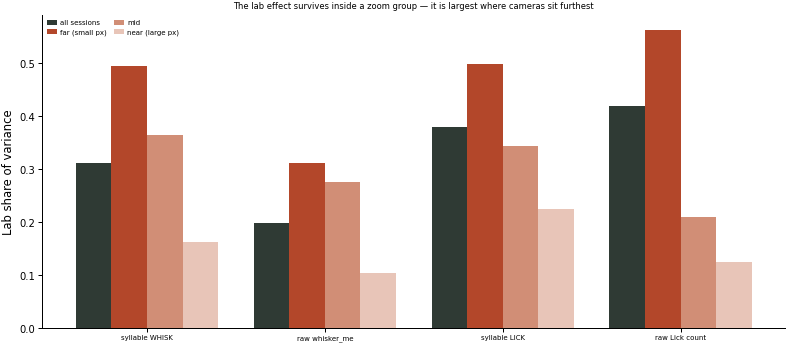

                 syllable WHISK  raw whisker_me  syllable LICK  raw Lick count
all                       0.312           0.200          0.380           0.420
far (small px)            0.495           0.312          0.499           0.564
mid                       0.365           0.276          0.345           0.210
near (large px)           0.162           0.104          0.226           0.125


In [7]:
"""LAB EFFECT WITHIN ZOOM GROUPS"""
grp = pd.qcut(zz, 3, labels=['far\n(small px)', 'mid', 'near\n(large px)'])
ct = pd.crosstab(grp, zlab)
print(f'labs spanning >1 zoom group: {int((ct > 0).sum(0).gt(1).sum())} of {ct.shape[1]}; '
      f'zoom groups with >1 lab: {int((ct > 0).sum(1).gt(1).sum())} of {ct.shape[0]}')

res = {}
for nm, D in CHAN.items():
    res[nm] = [partition(D, zlab, zms, n_perm=1500)[0]]          # all sessions
    for g in ct.index:
        idx = [o for o in zorder if grp[o] == g]
        res[nm].append(partition(D.loc[idx], zlab[idx], zms[idx], n_perm=1500)[0])

fig, ax = ps.figure('double', scale=.95)
x = np.arange(len(CHAN)); w = .2
cols = ['#2F3A34', '#B3472A', '#D18E76', '#E8C5B8']
for k, lab in enumerate(['all sessions'] + [str(g).replace('\n', ' ') for g in ct.index]):
    ax.bar(x + (k - 1.5) * w, [res[nm][k] for nm in CHAN], w, color=cols[k], label=lab)
ax.set_xticks(x); ax.set_xticklabels(list(CHAN), fontsize=plt.rcParams['font.size'] * .6)
ax.set_ylabel('Lab share of variance')
ax.legend(frameon=False, fontsize=plt.rcParams['font.size'] * .6, ncol=2)
ax.set_title('The lab effect survives inside a zoom group — it is largest where cameras sit furthest',
             fontsize=plt.rcParams['font.size'] * .72)
fig.tight_layout(); ps.savefig(fig, 'whisk_lick_lab_within_zoom', svg=True); plt.show()
print(pd.DataFrame(res, index=['all'] + [str(g).replace('\n', ' ') for g in ct.index]).round(3).to_string())

## What it says

**Does anything need normalising by zoom?** No — there was no lab effect to remove. Raw pixel
speed already reads 0.056 (p = 0.18). Correcting by nose-to-pupil takes it to exactly 0.000
(p = 0.70), so zoom accounts for a small, non-significant residue and nothing more. The
correction is worth doing for tidiness, not because it changes a conclusion.

| measure | n | lab | mouse | session | p |
|---|---|---|---|---|---|
| pixel speed (raw) | 269 | 0.056 | 0.599 | 0.345 | 0.18 |
| ÷ nose-to-pupil | 182 | **0.000** | 0.568 | 0.432 | 0.70 |
| ÷ tube length (wrong ruler) | 201 | 0.262 | 0.369 | 0.369 | 0.003 |
| state-occupancy vigor | 269 | 0.000 | 0.554 | 0.446 | 0.49 |
| lightningAction active fraction | 193 | 0.038 | 0.601 | 0.361 | 0.33 |

**Is dimensionlessness why the syllable and lightningAction measures are lab-free?** No, and
this is the important negative. If being a scale-free occupancy were what protects a measure
from lab variance, then the **whisk and lick occupancies would be lab-free too** — they are
exactly the same kind of quantity. They are instead the most lab-loaded channels in the whole
dataset: syllable whisk 0.208, syllable lick 0.345. So the encoding is not what determines
whether lab shows up; **what is being measured** is. Paw movement is lab-free in every
encoding tried — pixels, tube-lengths, nose-to-pupil units, state occupancy, classifier rate —
and whisk/lick is lab-loaded in every encoding too.

**And zoom does not explain the whisk/lick effect** (`zoom_and_lab_effects.py`). Zoom tertiles
cut across labs (6 of 9 labs span more than one), the lab effect survives inside a zoom group
and is largest in the far group (whisk 0.495, lick 0.499), and regressing out only the
WITHIN-LAB component of zoom — the part orthogonal to lab by construction — removes nothing.
No single lab carries it either: the smallest lab share after dropping any one lab is 0.183
for whisk and 0.210 for lick, all still p ≤ 0.003.

**Do whisk and lick scale with zoom at all?** Only licking, and the reason is in the pipeline:

| feature | r with zoom (session) | per mouse | normalised in the pipeline? |
|---|---|---|---|
| syllable WHISK | −0.017 (p = 0.82) | −0.098 | binary occupancy |
| raw `whisker_me` | −0.102 (p = 0.18) | −0.222 | **z-scored per session** |
| syllable LICK | −0.240 (p = 0.001) | −0.311 | binary occupancy |
| raw `Lick count` | **−0.516 (p = 2e-13)** | −0.553 | **a raw count — not normalised** |

`whisker_me` is a pixel motion-energy amplitude and *ought* to scale with magnification, but
`5_syllable_generation.ipynb` z-scores it per session, which removes any multiplicative gain
before it reaches the features. `Lick count` is the one channel that is neither z-scored nor
dimensionless, and it is the one that tracks zoom — strongly, and NEGATIVELY: a closer camera
yields *fewer* detected licks, which is not what simple magnification predicts and points at a
fixed pixel threshold in the detector rather than a scaling effect. The syllable lick state
inherits a weaker version of it (−0.24) through the HMM that is fitted on those counts.

**So:** lick detection is genuinely zoom-sensitive and worth fixing at source, whisking is not
zoom-sensitive at all, and neither channel's lab effect is explained by zoom.

**No contradiction with the wheel.** Matched on the same sessions, the scalar wheel is no more
lab-structured than scalar paw vigor (0.080 vs 0.090, both n.s.), and the paw *trajectory* is
lab-structured just as the wheel trajectory is (0.088, p < 0.001). The division is trajectory
versus scalar — collapsing 40 bins to a mean discards the shape, and the shape is where labs
differ. The wheel's remaining excess sits in the still periods: during the choice turn wheel
and paw agree (0.077 vs 0.074), and the gap opens in quiescence (0.175 vs 0.025), where the
wheel registers sub-threshold drift governed by its inertia, friction and the stillness
criterion. The wheel has no camera in its path at all, so whatever that is, it is not optics.

**Method note, now twice over:** a corrector that is lab-structured but does not predict the
outcome will manufacture or erase a lab effect at will — tube length here, geometry
residualisation in `1_lab_variance.ipynb`. Check that the corrector predicts what it corrects
before trusting what it does to the lab component.